# Macro Watch — Weekly Rates Brief

A weekly read on the **US Treasury and JGB curves** — outright tenors, slopes, butterflies, a PCA level/slope/curvature decomposition with rich/cheap, and weekly & daily transitions — with a cross-asset macro backdrop for context.

**Sources:** MoF Japan (JGB 2-40Y), FRED (UST 2-30Y, 10Y breakeven, WTI), Yahoo Finance (equity indices + gold).

**Pipeline:** `data_loader` → `analytics` → `visualizer` → Markdown brief.

In [1]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

# Make the package importable when running from inside macro_watch/.
sys.path.insert(0, str(Path.cwd().parent))

from macro_watch import analytics, visualizer
from macro_watch.data_loader import MacroDataLoader

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
visualizer.apply_style()

## 1. Ingest & cache

Instantiate the loader, (optionally) refresh the Parquet cache, and prepare the aligned business-day panel. Set `REFRESH = True` to re-fetch every source.

In [2]:
REFRESH = False  # set True to re-fetch all sources and rebuild the Parquet cache

loader = MacroDataLoader(cache_dir=Path.cwd().parent / "data_cache")
panel = loader.load(refresh=REFRESH)

print(f"Panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols")
print(f"Coverage: {panel.index.min().date()} -> {panel.index.max().date()}")
panel.tail()

Panel: 16,819 rows x 20 cols
Coverage: 1962-01-02 -> 2026-06-19


,US2Y,US3Y,US5Y,US7Y,US10Y,US20Y,US30Y,US10Y_BEI,JP2Y,JP5Y,JP10Y,JP20Y,JP30Y,JP40Y,WTI,GOLD,SPX,NDX,N225,TOPIX
date,,,,,,,,,,,,,,,,,,,,
2026-06-15,4.070,4.100,4.180,4.320,4.470,4.970,4.970,2.320,1.409,1.901,2.589,3.461,3.725,3.674,84.650,"4,328.000","7,554.290","26,683.939","69,317.500",NaN
2026-06-16,4.050,4.080,4.160,4.280,4.430,4.920,4.930,2.290,1.414,1.945,2.655,3.520,3.747,3.692,84.650,"4,330.900","7,511.350","26,376.340","69,404.500",NaN
2026-06-17,4.200,4.230,4.270,4.370,4.490,4.950,4.930,2.260,1.398,1.897,2.613,3.490,3.709,3.654,84.650,"4,358.900","7,420.100","26,021.660","69,902.250",NaN
2026-06-18,4.200,4.230,4.270,4.370,4.490,4.950,4.930,2.250,1.400,1.898,2.628,3.512,3.737,3.680,84.650,"4,224.100","7,500.580","26,517.930","71,053.492",NaN
2026-06-19,4.200,4.230,4.270,4.370,4.490,4.950,4.930,2.250,1.400,1.898,2.628,3.512,3.737,3.680,84.650,"4,172.900","7,500.580","26,517.930","71,250.062",NaN


## 2. US Treasury & JGB — curve, slopes & butterflies

The desk view: outright tenors, the full curve (incl. JGB super-longs), every standard slope and butterfly, and a PCA level/slope/curvature decomposition with 3-factor rich/cheap residuals.

### 2.1 Outright tenors (Δ in bps, momentum z-score)

In [3]:
tfmt = {"Yield(%)": "{:.3f}", "WoW(bp)": "{:+.1f}", "1M(bp)": "{:+.1f}", "Z_1W": "{:+.2f}"}
for market in ("US", "JP"):
    tbl = analytics.tenor_snapshot(panel, market)
    display(
        tbl.style.format(tfmt)
        .background_gradient(subset=["Z_1W"], cmap="RdBu_r", vmin=-3, vmax=3)
        .set_caption(f"{market} outright tenors")
    )

,Yield(%),WoW(bp),1M(bp),Z_1W
US2Y,4.200,+11.0,+7.0,+0.98
US3Y,4.230,+11.0,+5.0,+0.96
US5Y,4.270,+6.0,+0.0,+0.53
US7Y,4.370,+3.0,-4.0,+0.28
US10Y,4.490,+1.0,-7.0,+0.10
US20Y,4.950,-3.0,-11.0,-0.34
US30Y,4.930,-4.0,-14.0,-0.50


,Yield(%),WoW(bp),1M(bp),Z_1W
JP2Y,1.400,-1.7,-4.3,-0.47
JP5Y,1.898,-4.0,-12.8,-0.65
JP10Y,2.628,-1.5,-12.1,-0.19
JP20Y,3.512,+0.4,-13.2,+0.04
JP30Y,3.737,-3.0,-19.4,-0.34
JP40Y,3.680,-3.3,-24.1,-0.35


### 2.2 Curve snapshot & weekly shift

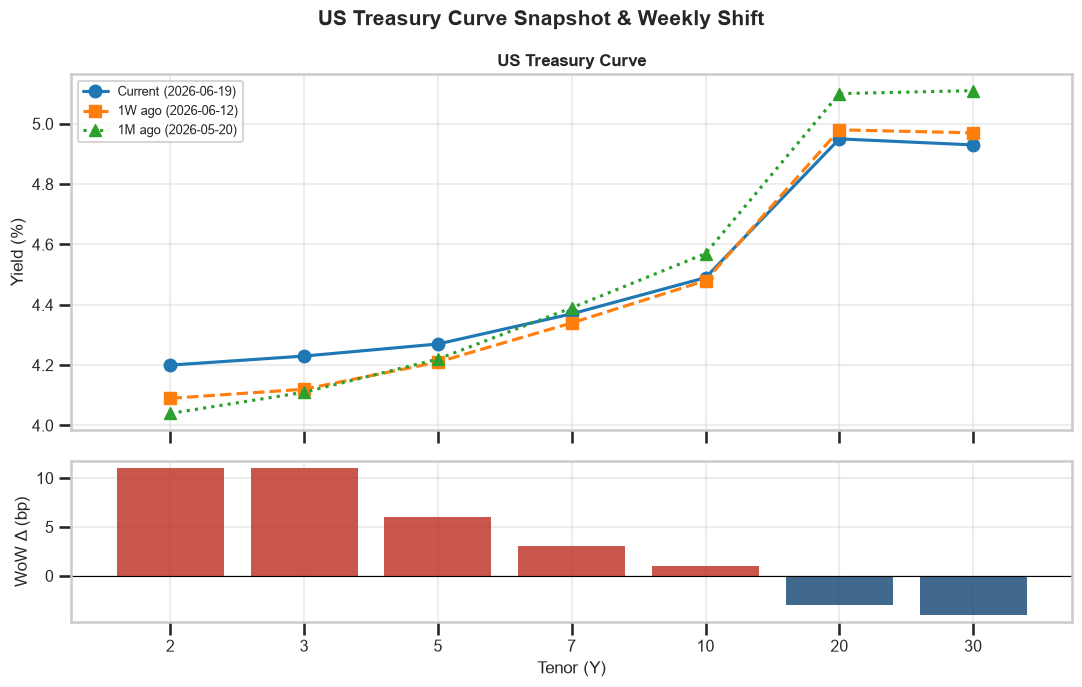

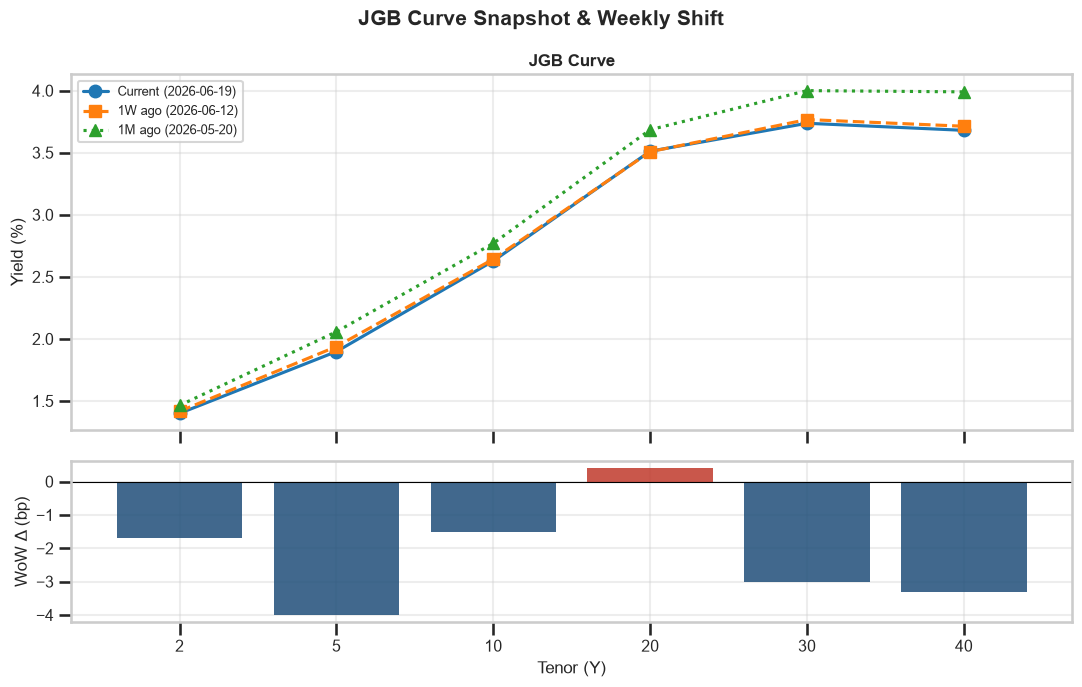

In [4]:
_ = visualizer.plot_curve_snapshot(panel, "US")
_ = visualizer.plot_curve_snapshot(panel, "JP")

### 2.3 Slopes & butterflies

`Z_1W` = vol-normalized weekly move (momentum); `Z_level` = richness of the current level vs its trailing 1y distribution; `Pctile` = percentile of the level over the trailing year.

**Butterflies are tenor-weighted** (belly richness vs the wings' yield/tenor interpolation), so the sign reflects true curvature even for unevenly-spaced flies — e.g. 5s10s20s, where the 10Y belly is far from the 12.5Y midpoint of 5s/20s. **Positive = belly cheap (belly yield above the wing line).** Pass `fly_weighting="equal"` to `curve_metrics` for the simple 2:1:1 Bloomberg-style fly.

The time-series panels plot the **actual spread (bp)** — slopes (steeper = up) and butterflies (belly cheap = up) — with the window mean and ±1σ/±2σ bands.

In [5]:
cfmt = {
    "Level(bp)": "{:+.1f}", "WoW(bp)": "{:+.1f}", "1M(bp)": "{:+.1f}",
    "Z_1W": "{:+.2f}", "Z_level": "{:+.2f}", "Pctile": "{:.0f}",
}
for market in ("US", "JP"):
    snap = analytics.rates_snapshot(panel, market)
    display(
        snap.style.format(cfmt)
        .background_gradient(subset=["Z_1W", "Z_level"], cmap="RdBu_r", vmin=-3, vmax=3)
        .set_caption(f"{market} slopes & butterflies")
    )

,Level(bp),WoW(bp),1M(bp),Z_1W,Z_level,Pctile,Kind
US_2s5s,+7.0,-5.0,-7.0,-1.25,-1.24,7,Slope
US_2s10s,+29.0,-10.0,-14.0,-1.69,-3.22,1,Slope
US_5s10s,+22.0,-5.0,-7.0,-1.41,-3.39,1,Slope
US_5s30s,+66.0,-10.0,-14.0,-1.43,-3.41,1,Slope
US_10s30s,+44.0,-5.0,-7.0,-1.21,-2.90,1,Slope
US_2s30s,+73.0,-15.0,-21.0,-1.73,-3.28,1,Slope
US_2s5s10s,-3.9,-1.2,-1.8,-0.49,+0.68,71,Fly
US_5s7s10s,+1.2,-1.0,-1.2,-0.68,-1.59,4,Fly
US_5s10s30s,+8.8,-3.0,-4.2,-1.26,-3.20,1,Fly
US_10s20s30s,+24.0,-1.5,-0.5,-0.85,-2.44,1,Fly


,Level(bp),WoW(bp),1M(bp),Z_1W,Z_level,Pctile,Kind
JP_2s10s,+122.8,+0.2,-7.8,+0.03,+1.87,92,Slope
JP_5s10s,+73.0,+2.5,+0.7,+0.77,+2.42,98,Slope
JP_10s20s,+88.4,+1.9,-1.1,+0.55,-0.92,24,Slope
JP_10s30s,+110.9,-1.5,-7.3,-0.27,-1.85,1,Slope
JP_20s30s,+22.5,-3.4,-6.2,-1.22,-2.46,1,Slope
JP_2s30s,+233.7,-1.3,-15.1,-0.16,+0.85,87,Slope
JP_5s30s,+183.9,+1.0,-6.6,+0.15,-0.41,40,Slope
JP_2s5s10s,+3.8,-2.4,-5.6,-1.28,-0.15,44,Fly
JP_5s10s20s,+19.2,+1.0,+0.8,+0.49,+2.21,98,Fly
JP_10s20s30s,+33.0,+2.6,+2.5,+1.70,+3.55,100,Fly


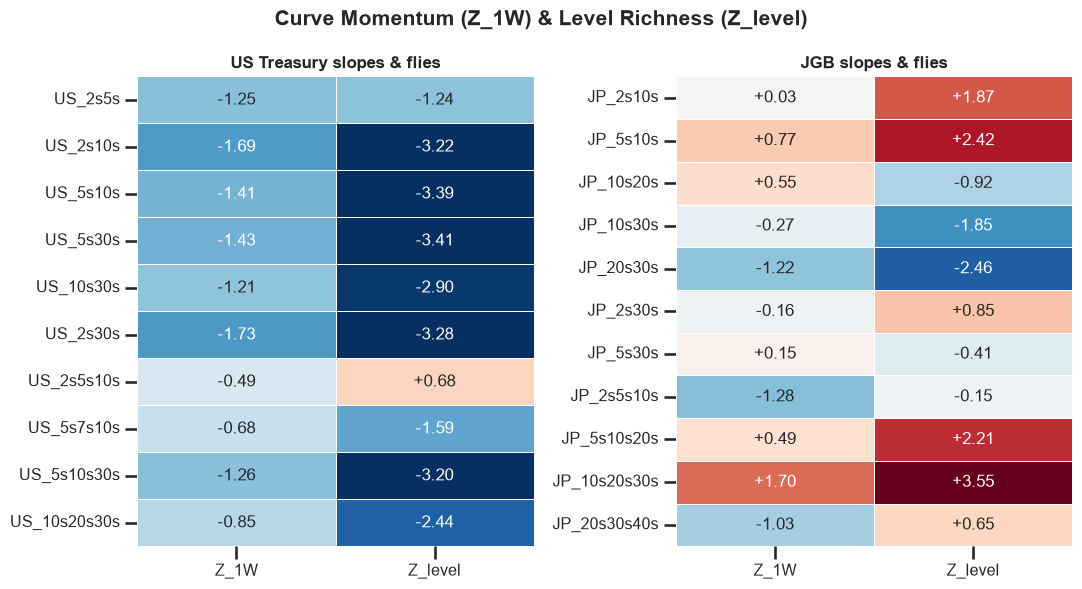

In [6]:
_ = visualizer.plot_rates_heatmap(panel)

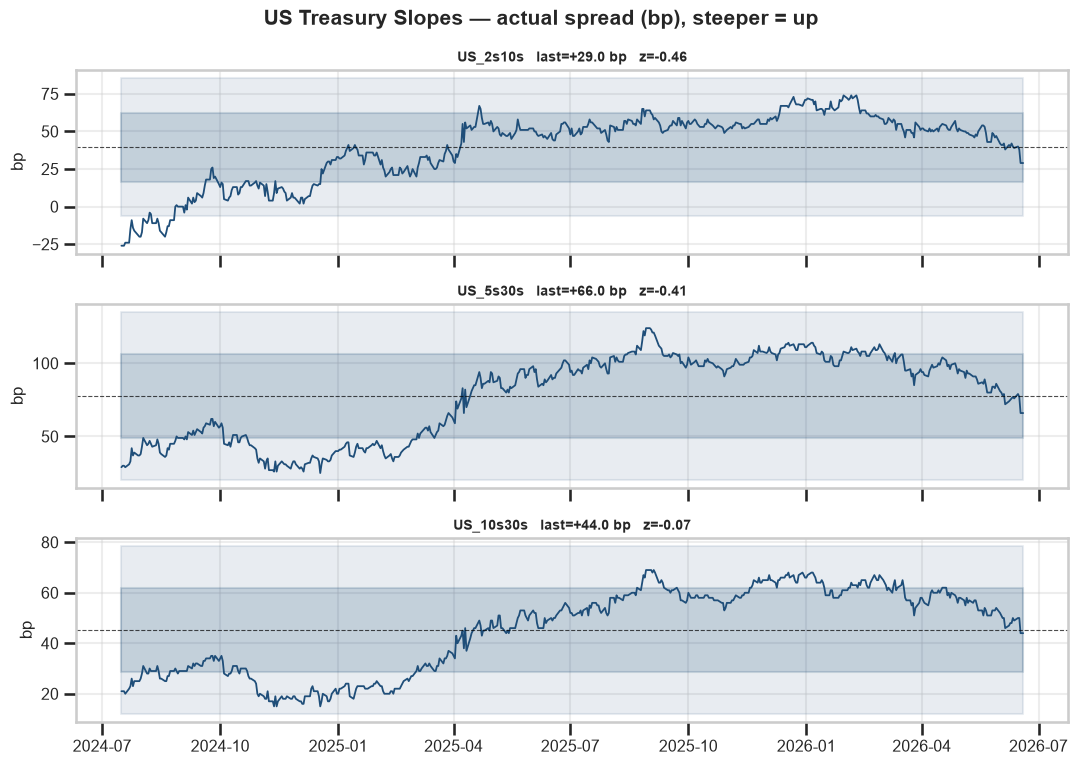

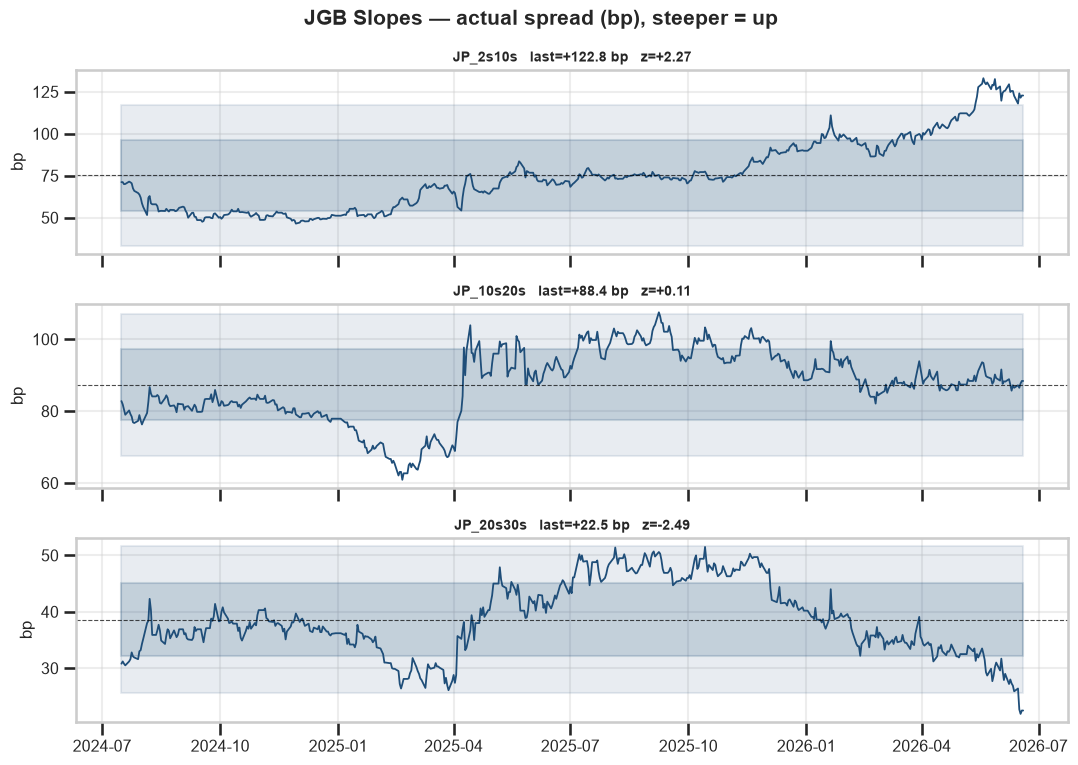

In [7]:
# Actual-spread time series (bp) for key slopes, both markets.
_ = visualizer.plot_spreads(panel, "US", ("US_2s10s", "US_5s30s", "US_10s30s"))
_ = visualizer.plot_spreads(panel, "JP", ("JP_2s10s", "JP_10s20s", "JP_20s30s"))

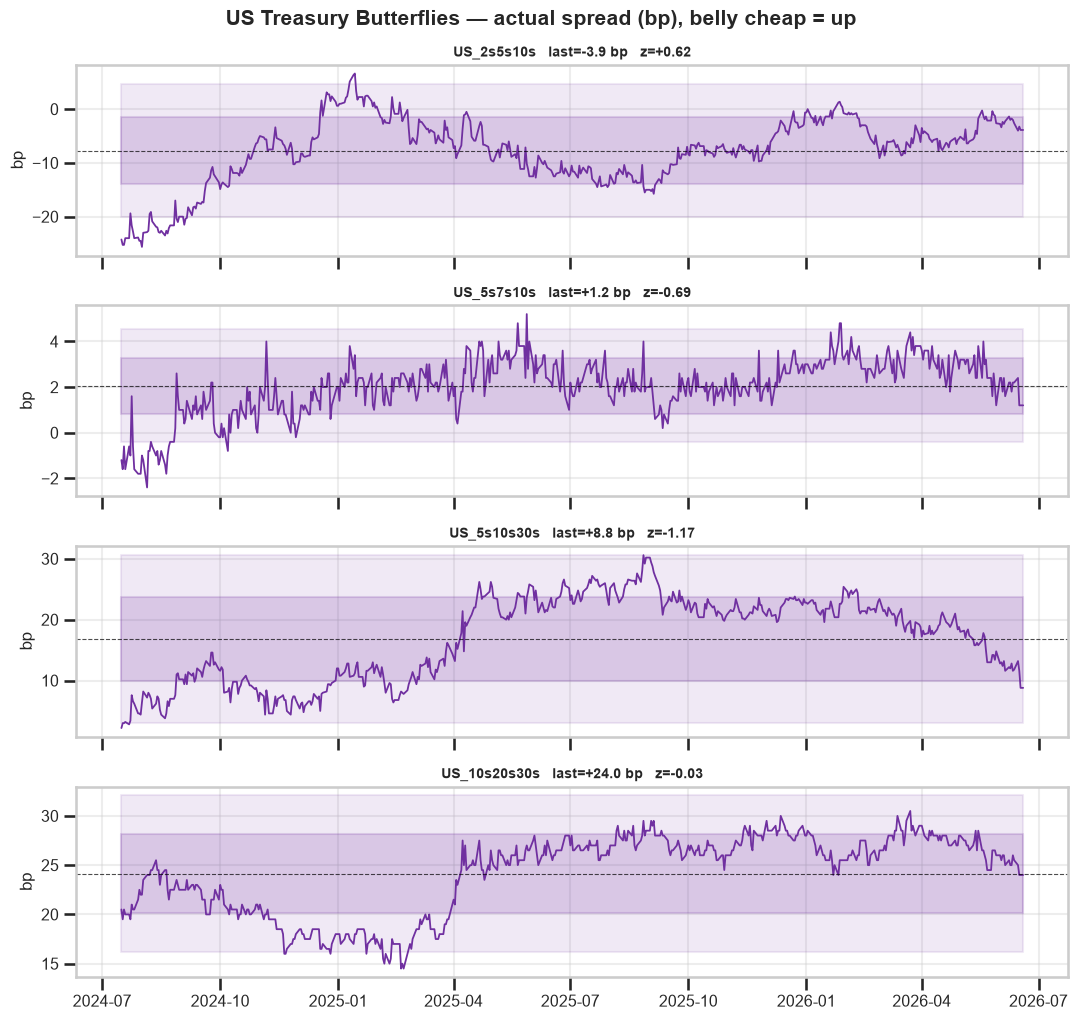

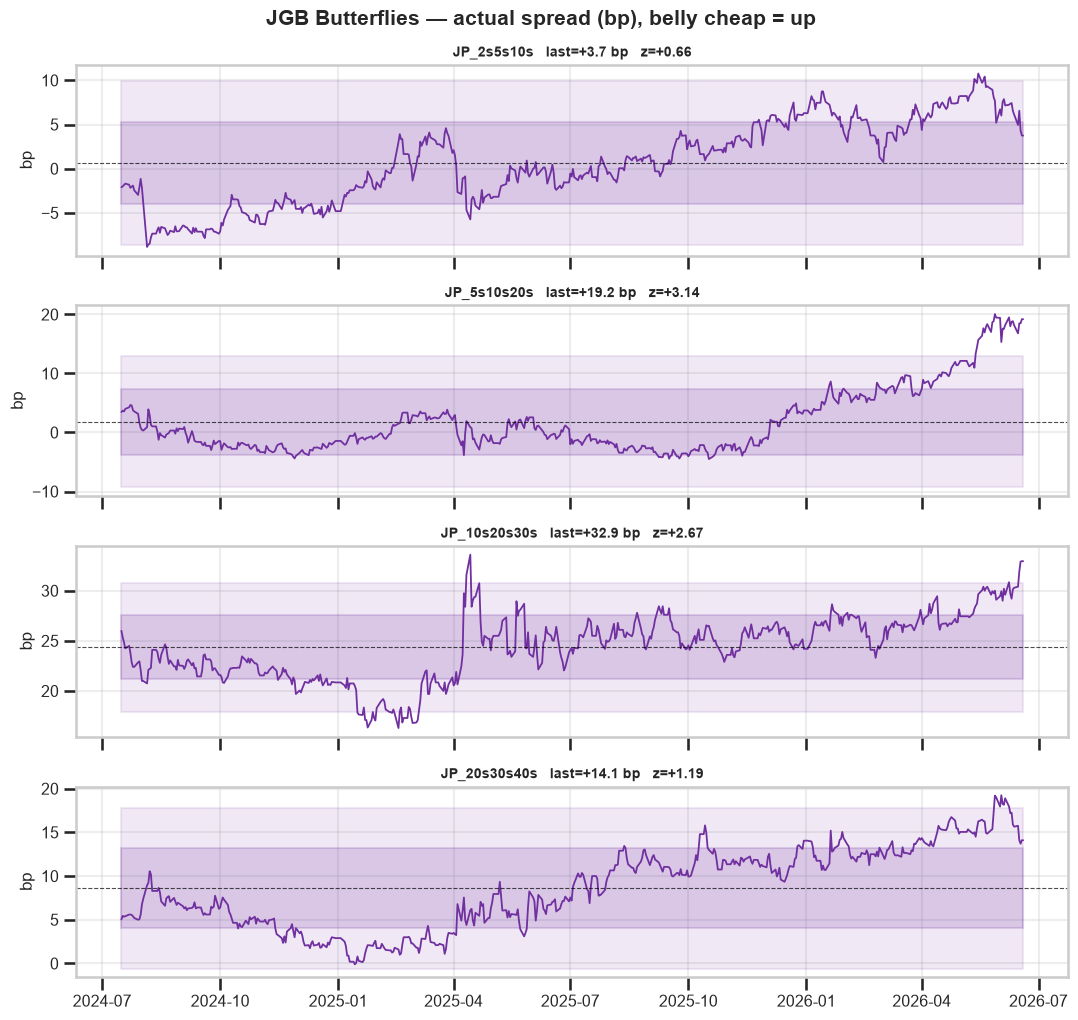

In [8]:
_ = visualizer.plot_butterflies(
    panel, "US", ("US_2s5s10s", "US_5s7s10s", "US_5s10s30s", "US_10s20s30s")
)
_ = visualizer.plot_butterflies(
    panel, "JP", ("JP_2s5s10s", "JP_5s10s20s", "JP_10s20s30s", "JP_20s30s40s")
)

### 2.4 Curve PCA — level / slope / curvature & rich-cheap

PCA on the trailing-year level curve. PC1≈level, PC2≈slope, PC3≈curvature (sign-normalized). The rich/cheap bars show each tenor's residual to the 3-factor reconstruction: **+ cheap (yields too high) / − rich**.

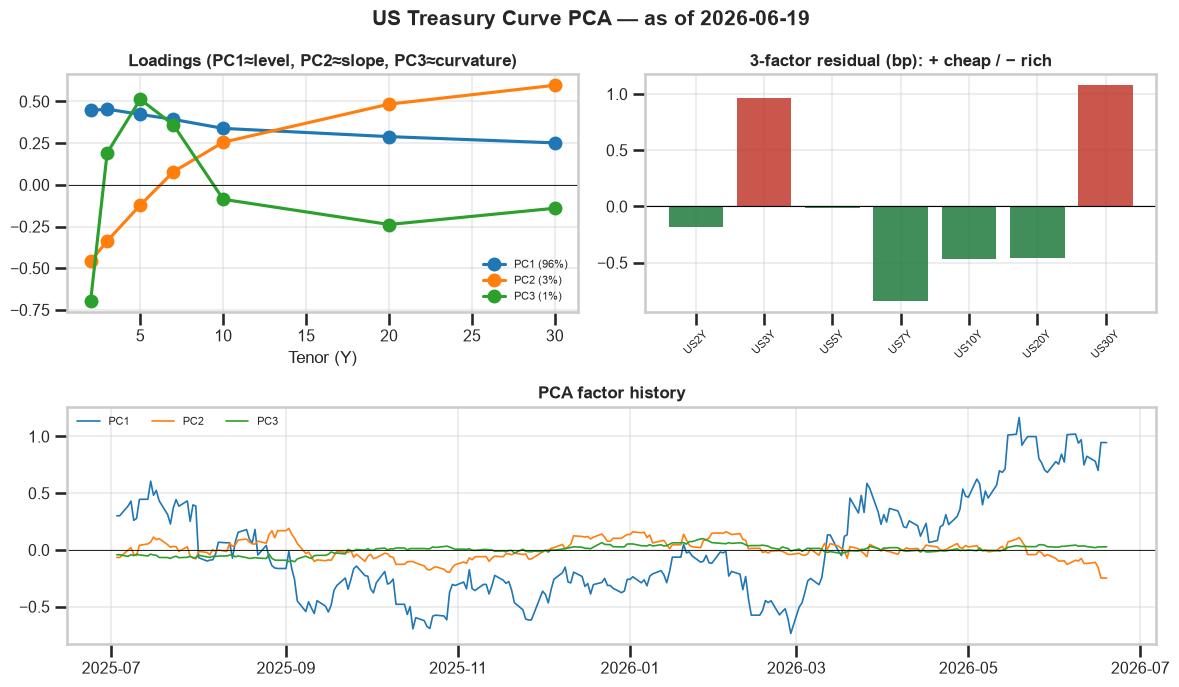

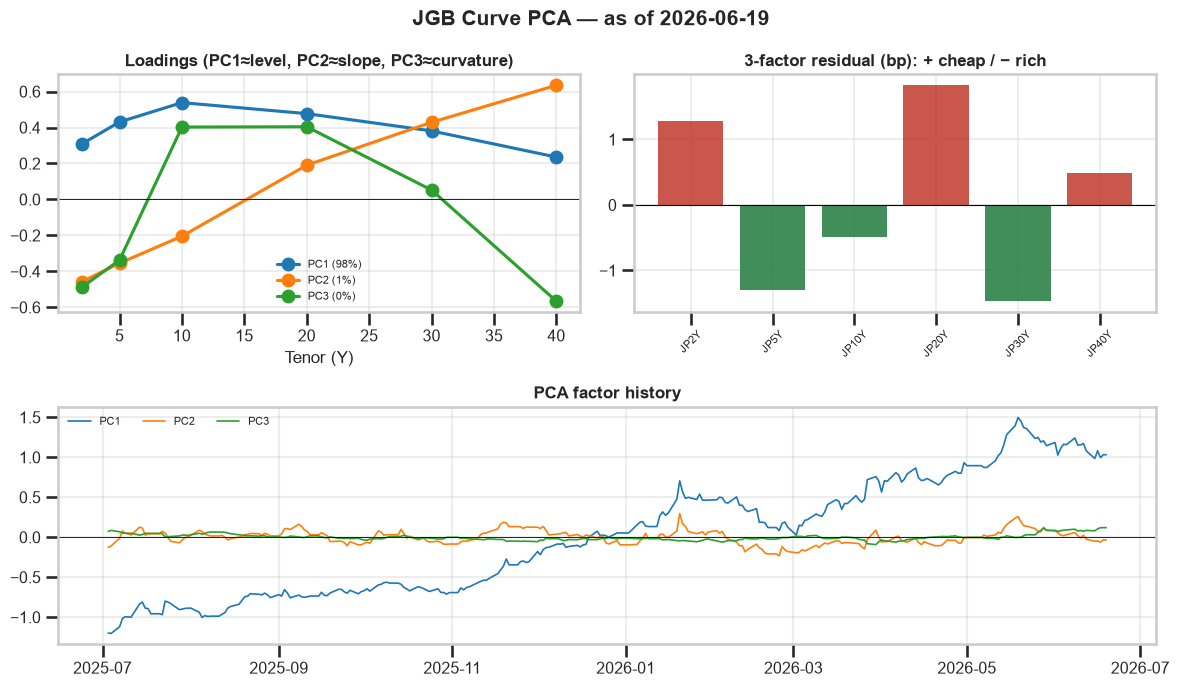

In [9]:
_ = visualizer.plot_curve_pca(panel, "US")
_ = visualizer.plot_curve_pca(panel, "JP")

### 2.5 Weekly transition

Week-ending (Friday close) levels across the last several weeks — the desk "transition" view. Tables show tenors (`%`), slopes and butterflies (`bp`) with the latest `WoW(bp)`; the plots overlay the full curve at each weekly close (oldest→newest) alongside the week-on-week change by tenor.

In [10]:
WEEKS = 8
for market in ("US", "JP"):
    trans = analytics.weekly_transition(panel, market, weeks=WEEKS)
    date_cols = [c for c in trans.columns if c not in ("Unit", "WoW(bp)")]
    sty = (
        trans.style.format("{:.3f}", subset=date_cols)
        .format({"WoW(bp)": "{:+.1f}"})
        .background_gradient(subset=["WoW(bp)"], cmap="RdBu_r", vmin=-15, vmax=15)
        .set_caption(f"{market} weekly transition (last {WEEKS} weekly closes)")
    )
    display(sty)

,Unit,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29,2026-06-05,2026-06-12,2026-06-19,WoW(bp)
US2Y,%,3.880000,3.900000,4.090000,4.130000,3.980000,4.170000,4.090000,4.200000,+11.0
US3Y,%,3.910000,3.920000,4.140000,4.180000,4.060000,4.220000,4.120000,4.230000,+11.0
US5Y,%,4.020000,4.020000,4.260000,4.270000,4.130000,4.290000,4.210000,4.270000,+6.0
US7Y,%,4.200000,4.190000,4.430000,4.410000,4.270000,4.410000,4.340000,4.370000,+3.0
US10Y,%,4.390000,4.380000,4.590000,4.560000,4.450000,4.550000,4.480000,4.490000,+1.0
US20Y,%,4.960000,4.930000,5.140000,5.060000,4.980000,5.030000,4.980000,4.950000,-3.0
US30Y,%,4.970000,4.950000,5.120000,5.070000,4.990000,5.010000,4.970000,4.930000,-4.0
US_2s5s,bp,14.000000,12.000000,17.000000,14.000000,15.000000,12.000000,12.000000,7.000000,-5.0
US_2s10s,bp,51.000000,48.000000,50.000000,43.000000,47.000000,38.000000,39.000000,29.000000,-10.0
US_5s10s,bp,37.000000,36.000000,33.000000,29.000000,32.000000,26.000000,27.000000,22.000000,-5.0


,Unit,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29,2026-06-05,2026-06-12,2026-06-19,WoW(bp)
JP2Y,%,1.385000,1.378000,1.413000,1.443000,1.393000,1.412000,1.417000,1.400000,-1.7
JP5Y,%,1.888000,1.875000,2.000000,2.026000,1.919000,1.955000,1.938000,1.898000,-4.0
JP10Y,%,2.507000,2.485000,2.691000,2.749000,2.657000,2.669000,2.643000,2.628000,-1.5
JP20Y,%,3.381000,3.369000,3.603000,3.644000,3.549000,3.551000,3.508000,3.512000,+0.4
JP30Y,%,3.706000,3.706000,3.922000,3.931000,3.859000,3.841000,3.767000,3.737000,-3.0
JP40Y,%,3.730000,3.739000,3.916000,3.921000,3.789000,3.753000,3.713000,3.680000,-3.3
JP_2s10s,bp,112.200000,110.700000,127.800000,130.600000,126.400000,125.700000,122.600000,122.800000,+0.2
JP_5s10s,bp,61.900000,61.000000,69.100000,72.300000,73.800000,71.400000,70.500000,73.000000,+2.5
JP_10s20s,bp,87.400000,88.400000,91.200000,89.500000,89.200000,88.200000,86.500000,88.400000,+1.9
JP_10s30s,bp,119.900000,122.100000,123.100000,118.200000,120.200000,117.200000,112.400000,110.900000,-1.5


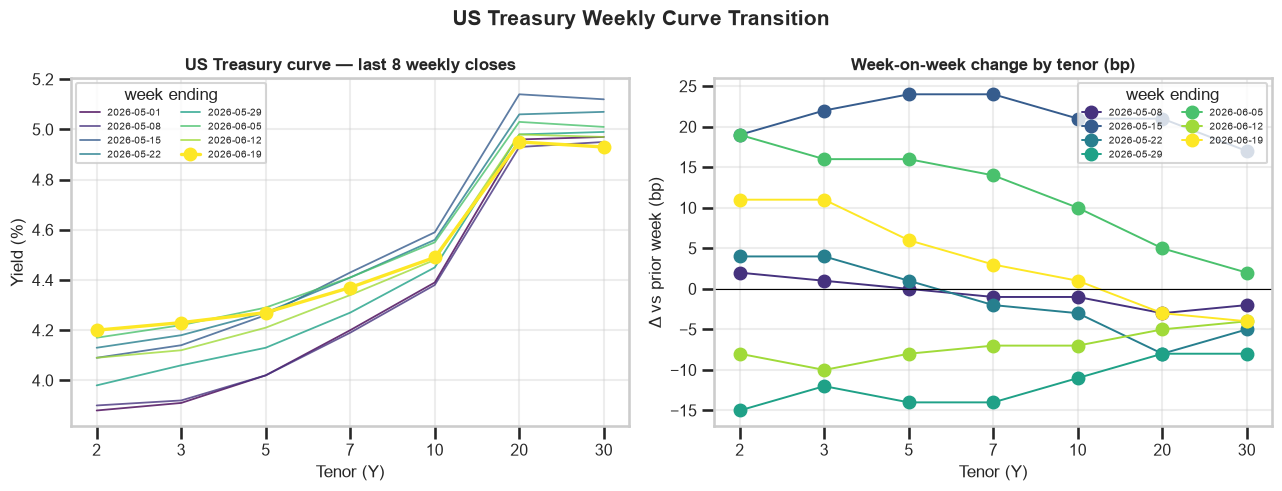

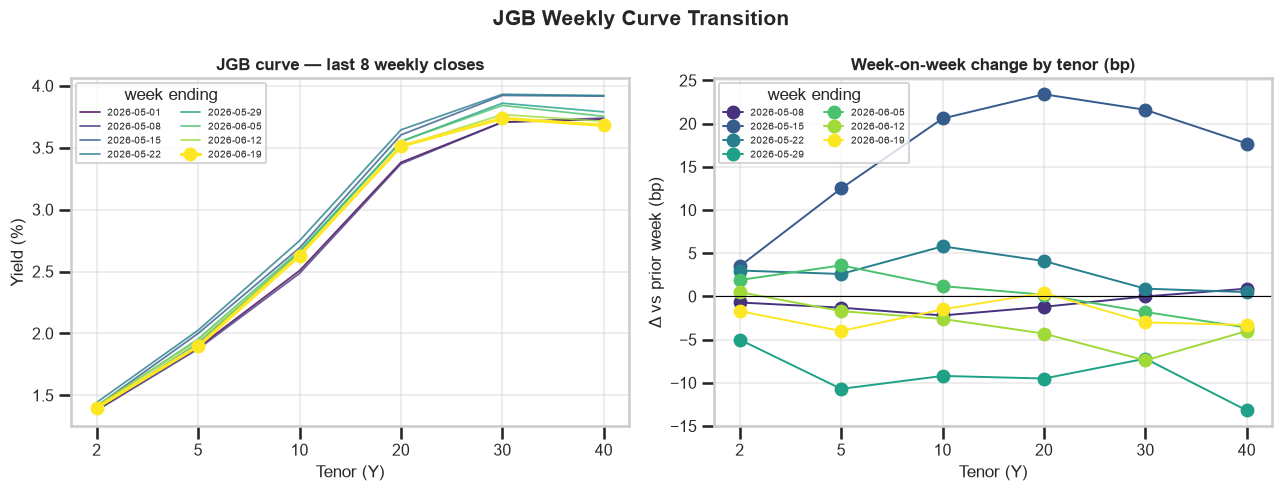

In [11]:
_ = visualizer.plot_curve_transition(panel, "US", weeks=WEEKS)
_ = visualizer.plot_curve_transition(panel, "JP", weeks=WEEKS)

**Butterfly weekly transition** — each fly's tenor-weighted level (bp) at the last `WEEKS` weekly closes (belly cheap = up).

,Unit,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29,2026-06-05,2026-06-12,2026-06-19,WoW(bp)
US_2s5s10s,bp,-5.125000,-6.000000,-1.750000,-2.125000,-2.625000,-2.250000,-2.625000,-3.875000,-1.2
US_5s7s10s,bp,3.200000,2.600000,3.800000,2.400000,1.200000,1.600000,2.200000,1.200000,-1.0
US_5s10s30s,bp,18.000000,17.400000,15.800000,13.000000,14.800000,11.600000,11.800000,8.800000,-3.0
US_10s20s30s,bp,28.000000,26.500000,28.500000,24.500000,26.000000,25.000000,25.500000,24.000000,-1.5


,Unit,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29,2026-06-05,2026-06-12,2026-06-19,WoW(bp)
JP_2s5s10s,bp,8.225000,8.188000,10.775000,9.325000,5.200000,7.163000,6.125000,3.750000,-2.4
JP_5s10s20s,bp,12.133000,11.200000,15.667000,18.367000,19.467000,18.200000,18.167000,19.200000,+1.0
JP_10s20s30s,bp,27.450000,27.350000,29.650000,30.400000,29.100000,29.600000,30.300000,32.950000,+2.6
JP_20s30s40s,bp,15.050000,15.200000,16.250000,14.850000,19.000000,18.900000,15.650000,14.100000,-1.6


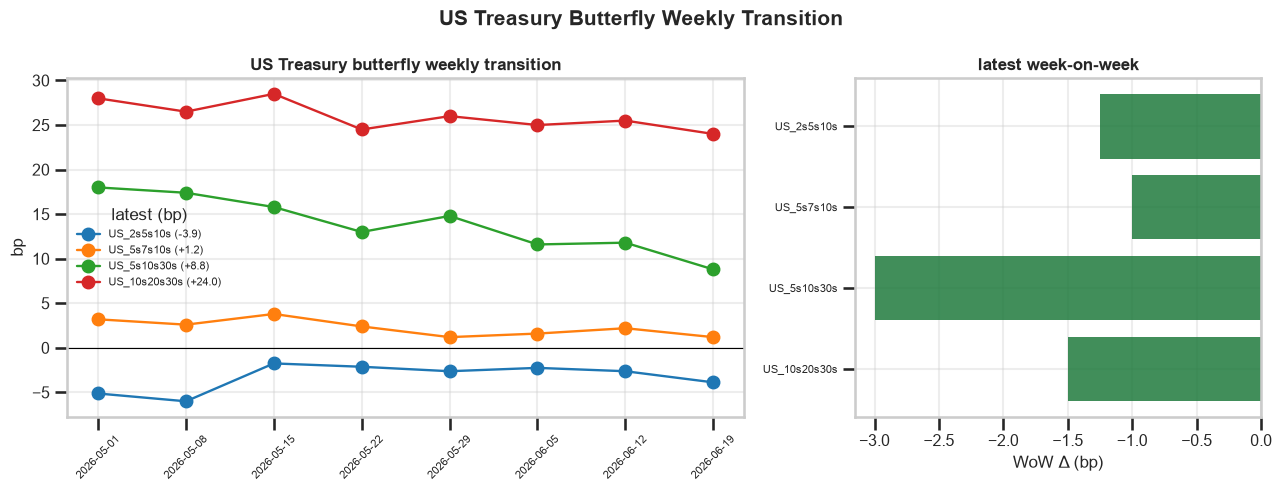

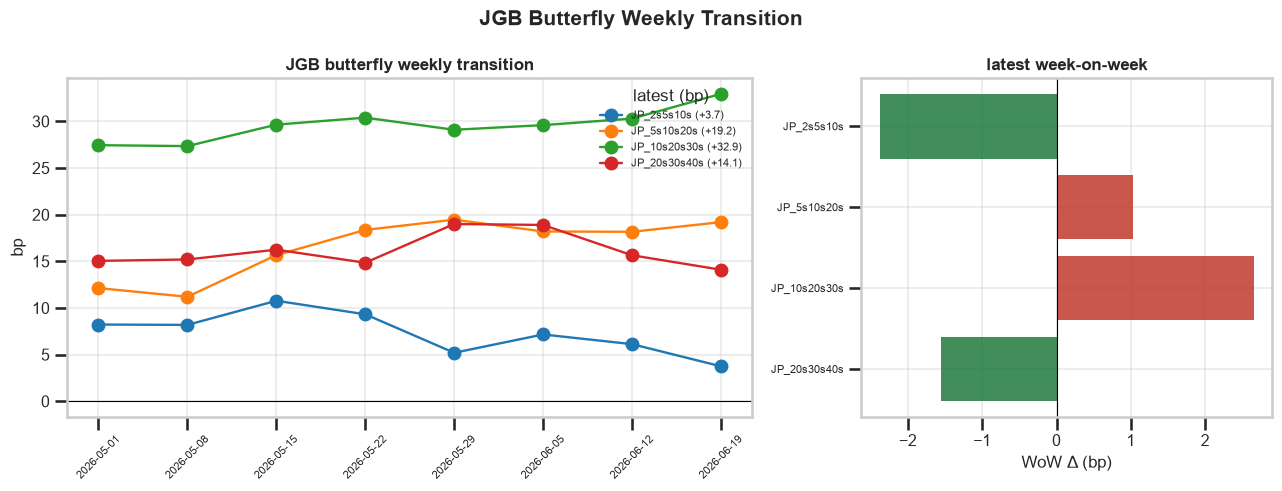

In [12]:
FLIES = {
    "US": ("US_2s5s10s", "US_5s7s10s", "US_5s10s30s", "US_10s20s30s"),
    "JP": ("JP_2s5s10s", "JP_5s10s20s", "JP_10s20s30s", "JP_20s30s40s"),
}
for market in ("US", "JP"):
    tbl = analytics.weekly_transition(panel, market, weeks=WEEKS, kind="fly")
    date_cols = [c for c in tbl.columns if c not in ("Unit", "WoW(bp)")]
    display(
        tbl.style.format("{:+.1f}", subset=date_cols)
        .format({"WoW(bp)": "{:+.1f}"})
        .background_gradient(subset=["WoW(bp)"], cmap="RdBu_r", vmin=-10, vmax=10)
        .set_caption(f"{market} butterfly weekly transition (bp, belly cheap = +)")
    )
    _ = visualizer.plot_spread_transition(panel, market, FLIES[market], weeks=WEEKS)

**Butterfly — last week (daily)** — the daily path of each fly over the last week (5 sessions); `WoW(bp)` is the trailing 5-session change. The chart shades the last week and bars the WoW move per fly.

,Unit,2026-06-15,2026-06-16,2026-06-17,2026-06-18,2026-06-19,WoW(bp)
US_2s5s10s,bp,-4.000000,-3.250000,-3.875000,-3.875000,-3.875000,-1.2
US_5s7s10s,bp,2.400000,1.200000,1.200000,1.200000,1.200000,-1.0
US_5s10s30s,bp,13.200000,11.600000,8.800000,8.800000,8.800000,-3.0
US_10s20s30s,bp,25.000000,24.000000,24.000000,24.000000,24.000000,-1.5


,Unit,2026-06-15,2026-06-16,2026-06-17,2026-06-18,2026-06-19,WoW(bp)
JP_2s5s10s,bp,4.950000,6.563000,4.337000,3.750000,3.750000,-2.4
JP_5s10s20s,bp,16.800000,18.500000,18.500000,19.200000,19.200000,+1.0
JP_10s20s30s,bp,30.400000,31.900000,32.900000,32.950000,32.950000,+2.6
JP_20s30s40s,bp,15.750000,14.100000,13.700000,14.100000,14.100000,-1.6


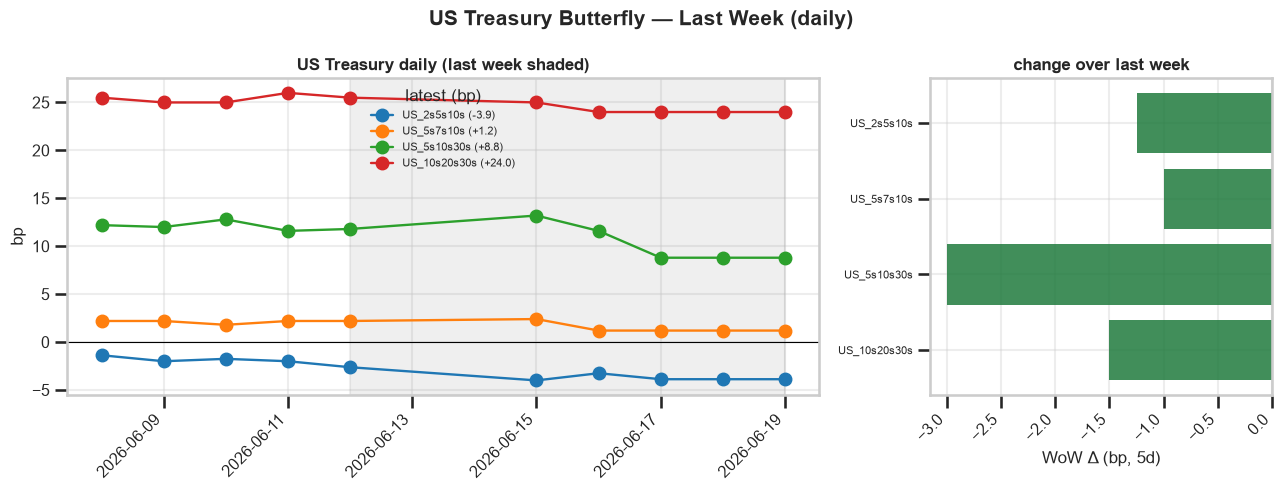

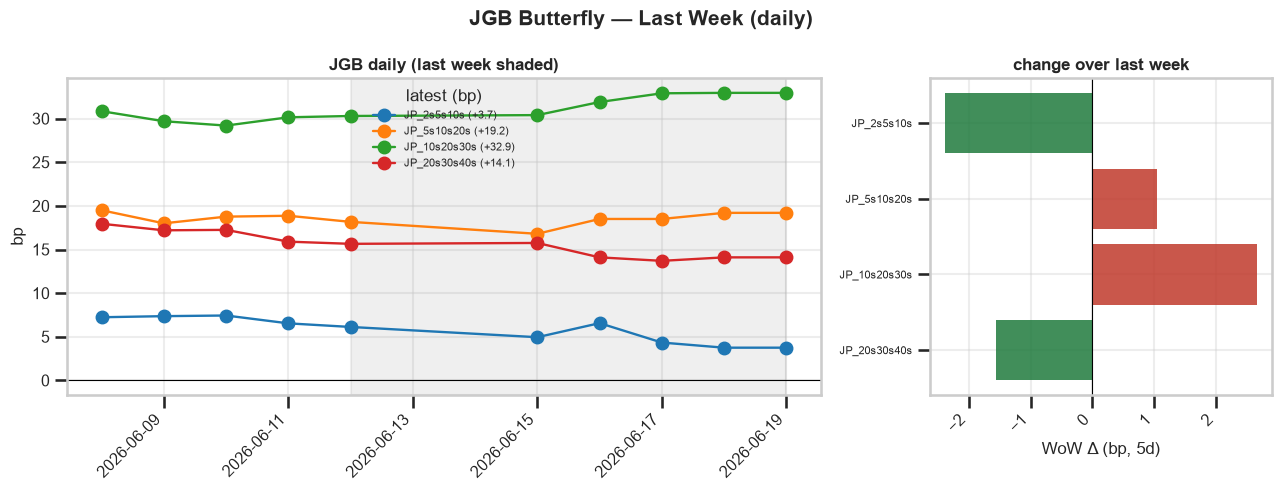

In [13]:
for market in ("US", "JP"):
    tbl = analytics.daily_transition(panel, market, sessions=5, kind="fly")
    date_cols = [c for c in tbl.columns if c not in ("Unit", "WoW(bp)")]
    display(
        tbl.style.format("{:+.1f}", subset=date_cols)
        .format({"WoW(bp)": "{:+.1f}"})
        .background_gradient(subset=["WoW(bp)"], cmap="RdBu_r", vmin=-10, vmax=10)
        .set_caption(f"{market} butterfly daily — last week (bp, belly cheap = +)")
    )
    _ = visualizer.plot_spread_daily(panel, market, FLIES[market], sessions=10)

## 3. Cross-asset macro backdrop

Context for the rates view: weekly momentum across rates, equities and commodities, plus the macro decoupling and rolling-correlation trackers.

In [14]:
summary = analytics.weekly_summary(panel)
print(f"As of: {summary.as_of.date()}")

fmt = {"Level": "{:,.3f}", "WoW": "{:+,.3f}", "Z_1W": "{:+.2f}", "Z_4W": "{:+.2f}"}
summary.table.style.format(fmt).background_gradient(
    subset=["Z_1W", "Z_4W"], cmap="RdBu_r", vmin=-3, vmax=3
)

As of: 2026-06-19


,Level,WoW,Z_1W,Z_4W,Type
US2Y,4.200,+0.110,+0.98,+0.31,Yield/Spread
US3Y,4.230,+0.110,+0.96,+0.22,Yield/Spread
US5Y,4.270,+0.060,+0.53,+0.00,Yield/Spread
US7Y,4.370,+0.030,+0.27,-0.18,Yield/Spread
US10Y,4.490,+0.010,+0.10,-0.35,Yield/Spread
US20Y,4.950,-0.030,-0.34,-0.62,Yield/Spread
US30Y,4.930,-0.040,-0.50,-0.87,Yield/Spread
US10Y_BEI,2.250,-0.060,-1.25,-1.56,Yield/Spread
JP2Y,1.400,-0.017,-0.47,-0.59,Yield/Spread
JP5Y,1.898,-0.040,-0.65,-1.04,Yield/Spread


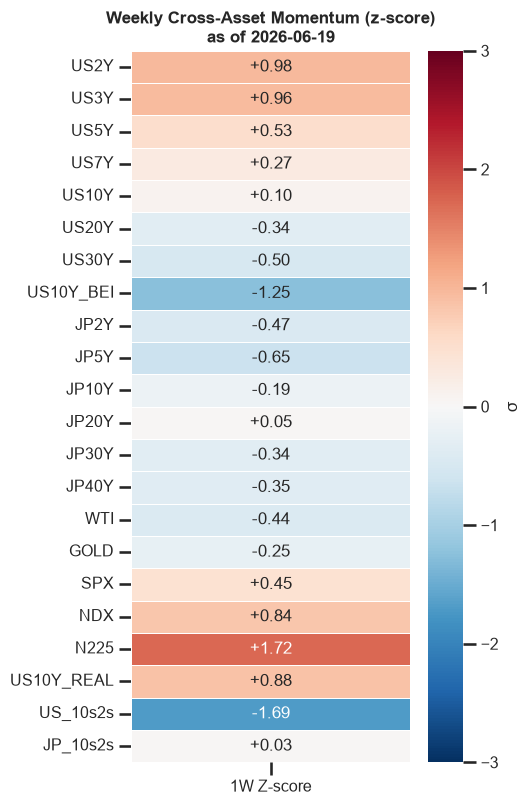

In [15]:
_ = visualizer.plot_weekly_heatmap(panel)

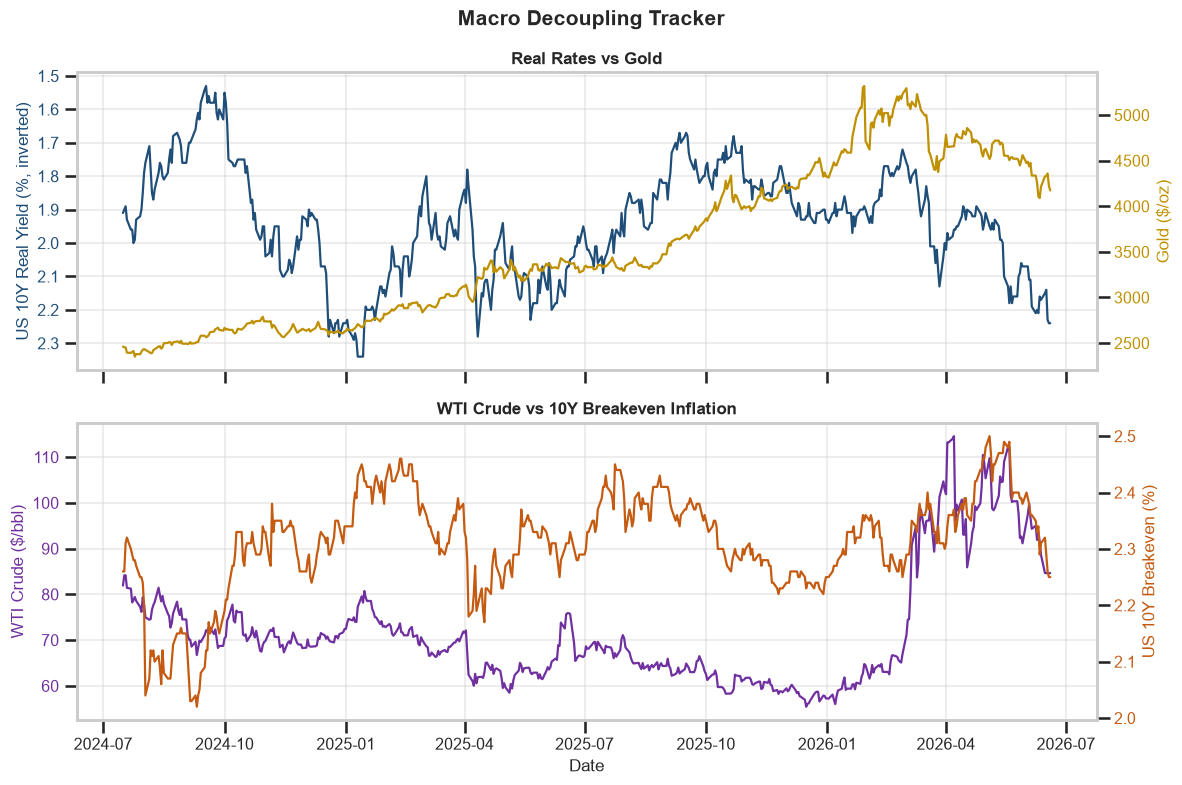

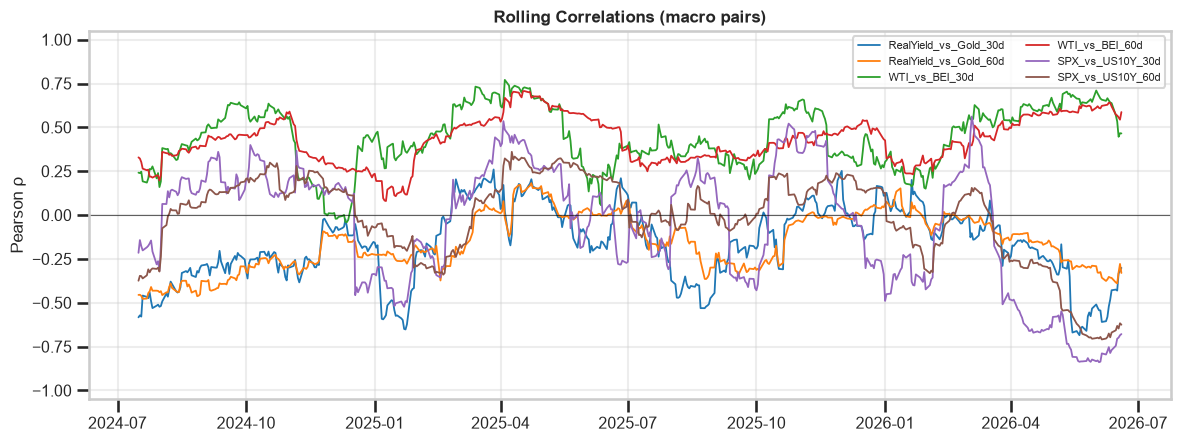

In [16]:
_ = visualizer.plot_decoupling(panel)
_ = visualizer.plot_rolling_correlations(summary.correlations)

## 4. Weekly brief (Markdown)

Largest curve moves (by |z|) on each rates market, plus cross-asset OHLC for the final week.

In [17]:
ohlc = summary.ohlc.join(summary.table[["WoW", "Z_1W", "Type"]])
ohlc = ohlc[["Open", "High", "Low", "Close", "WoW", "Z_1W", "Type"]].round(3)

cols = ["Level(bp)", "WoW(bp)", "Z_1W", "Z_level", "Pctile"]

def top_moves(market: str, k: int = 5) -> pd.DataFrame:
    s = analytics.rates_snapshot(panel, market)
    return s.loc[s["Z_1W"].abs().sort_values(ascending=False).index[:k], cols]

md = (
    f"### Weekly Rates Brief — week ending {summary.as_of.date()}\n\n"
    "#### US Treasury — largest curve moves (|z|)\n\n"
    + top_moves("US").to_markdown(floatfmt="+.2f")
    + "\n\n#### JGB — largest curve moves (|z|)\n\n"
    + top_moves("JP").to_markdown(floatfmt="+.2f")
    + "\n\n#### Cross-asset backdrop — OHLC\n\n"
    + ohlc.to_markdown(floatfmt="+.3f")
)
Markdown(md)

### Weekly Rates Brief — week ending 2026-06-19

#### US Treasury — largest curve moves (|z|)

|             |   Level(bp) |   WoW(bp) |   Z_1W |   Z_level |   Pctile |
|:------------|------------:|----------:|-------:|----------:|---------:|
| US_2s30s    |      +73.00 |    -15.00 |  -1.73 |     -3.28 |    +0.79 |
| US_2s10s    |      +29.00 |    -10.00 |  -1.69 |     -3.22 |    +0.79 |
| US_5s30s    |      +66.00 |    -10.00 |  -1.43 |     -3.41 |    +0.79 |
| US_5s10s    |      +22.00 |     -5.00 |  -1.41 |     -3.39 |    +0.79 |
| US_5s10s30s |       +8.80 |     -3.00 |  -1.26 |     -3.20 |    +0.79 |

#### JGB — largest curve moves (|z|)

|              |   Level(bp) |   WoW(bp) |   Z_1W |   Z_level |   Pctile |
|:-------------|------------:|----------:|-------:|----------:|---------:|
| JP_10s20s30s |      +32.95 |     +2.65 |  +1.70 |     +3.55 |   +99.80 |
| JP_2s5s10s   |       +3.75 |     -2.38 |  -1.28 |     -0.15 |   +44.05 |
| JP_20s30s    |      +22.50 |     -3.40 |  -1.22 |     -2.46 |    +0.99 |
| JP_20s30s40s |      +14.10 |     -1.55 |  -1.03 |     +0.65 |   +76.39 |
| JP_5s10s     |      +73.00 |     +2.50 |  +0.77 |     +2.42 |   +97.82 |

#### Cross-asset backdrop — OHLC

|            |       Open |       High |        Low |      Close |      WoW |     Z_1W | Type         |
|:-----------|-----------:|-----------:|-----------:|-----------:|---------:|---------:|:-------------|
| US2Y       |     +4.070 |     +4.200 |     +4.050 |     +4.200 |   +0.110 |   +0.976 | Yield/Spread |
| US3Y       |     +4.100 |     +4.230 |     +4.080 |     +4.230 |   +0.110 |   +0.960 | Yield/Spread |
| US5Y       |     +4.180 |     +4.270 |     +4.160 |     +4.270 |   +0.060 |   +0.525 | Yield/Spread |
| US7Y       |     +4.320 |     +4.370 |     +4.280 |     +4.370 |   +0.030 |   +0.275 | Yield/Spread |
| US10Y      |     +4.470 |     +4.490 |     +4.430 |     +4.490 |   +0.010 |   +0.101 | Yield/Spread |
| US20Y      |     +4.970 |     +4.970 |     +4.920 |     +4.950 |   -0.030 |   -0.336 | Yield/Spread |
| US30Y      |     +4.970 |     +4.970 |     +4.930 |     +4.930 |   -0.040 |   -0.499 | Yield/Spread |
| US10Y_BEI  |     +2.320 |     +2.320 |     +2.250 |     +2.250 |   -0.060 |   -1.245 | Yield/Spread |
| JP2Y       |     +1.409 |     +1.414 |     +1.398 |     +1.400 |   -0.017 |   -0.467 | Yield/Spread |
| JP5Y       |     +1.901 |     +1.945 |     +1.897 |     +1.898 |   -0.040 |   -0.648 | Yield/Spread |
| JP10Y      |     +2.589 |     +2.655 |     +2.589 |     +2.628 |   -0.015 |   -0.186 | Yield/Spread |
| JP20Y      |     +3.461 |     +3.520 |     +3.461 |     +3.512 |   +0.004 |   +0.045 | Yield/Spread |
| JP30Y      |     +3.725 |     +3.747 |     +3.709 |     +3.737 |   -0.030 |   -0.335 | Yield/Spread |
| JP40Y      |     +3.674 |     +3.692 |     +3.654 |     +3.680 |   -0.033 |   -0.352 | Yield/Spread |
| WTI        |    +84.650 |    +84.650 |    +84.650 |    +84.650 |   -0.046 |   -0.441 | Price        |
| GOLD       |  +4328.000 |  +4358.900 |  +4172.900 |  +4172.900 |   -0.010 |   -0.253 | Price        |
| SPX        |  +7554.290 |  +7554.290 |  +7420.100 |  +7500.580 |   +0.009 |   +0.453 | Price        |
| NDX        | +26683.939 | +26683.939 | +26021.660 | +26517.930 |   +0.024 |   +0.838 | Price        |
| N225       | +69317.500 | +71250.062 | +69317.500 | +71250.062 |   +0.076 |   +1.724 | Price        |
| TOPIX      |   +nan     |   +nan     |   +nan     |   +nan     | +nan     | +nan     | Price        |
| US10Y_REAL |     +2.150 |     +2.240 |     +2.140 |     +2.240 |   +0.070 |   +0.885 | Yield/Spread |
| US_10s2s   |    +40.000 |    +40.000 |    +29.000 |    +29.000 |  -10.000 |   -1.688 | Yield/Spread |
| JP_10s2s   |   +118.000 |   +124.100 |   +118.000 |   +122.800 |   +0.200 |   +0.032 | Yield/Spread |

In [18]:
out_path = Path.cwd().parent / "data_cache" / f"weekly_brief_{summary.as_of.date()}.md"
out_path.write_text(md)
print(f"Saved -> {out_path}")

Saved -> /Users/keitafujie/Documents/macro/data_cache/weekly_brief_2026-06-19.md
